In [1]:
import os
import copy
import json
import time
from pathlib import Path
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from dateutil.relativedelta import relativedelta
import sys
sys.path.append("../src")
from dateutil.relativedelta import relativedelta

from Models.model import GLSTM_v2
from Data.file_utils import create_next_experiment_folder
from Models.models_utils import reset_weights
from Data.prepare_data import *
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore,
                                add_consecutive_dry_days_feature)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     #haversine_km,
                                     tensor_data_precip,
                                     era5_specific_humidity_tensor,
                                     forecast_steps_to_daily_precip,
                                     era5_daily_precip_all,
                                     daily_precip_dataset_to_tensor,
                                     get_wind_uv
                                     )     
          
from Evaluation.metrics import safe_r2, safe_mape, combined_loss, weighted_mse_loss
from Evaluation.comparison_plots import save_error_plots, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn, scatter_true_pred
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, distance_graph
from Training.Training_Routines import train_stable


device = "cuda" if torch.cuda.is_available() else "cpu"

RUN_MODE = "quick"  # quick or full
if RUN_MODE == "full":
    start_date = "2000-01-01"
    end_date   = "2025-12-31"

elif RUN_MODE == "custom":
    start_date = "2010-01-01"
    end_date   = "2025-12-31"

else:
    start_date = "2024-01-01"
    end_date   = "2025-12-31"

T = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1

eps          = 1e-6
window_size  = 45
horizon      = 1
criterion_km = 120
lstm_layers  = 1
dropout      = 0.3
K            = 4
batch_size   = 64
num_workers  = 0
vertex_idx   = 32
weight_decay = 5e-4
T_max = 50
test_lstm    = False
learn_adj    = True
loss_fn = nn.HuberLoss(delta=5)
topology     = 'knn'  # 'knn' ou 'distance'


z_score = False


catalog_dir = Path(os.path.join("..", "Datasets", "dados_inmet"))
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)



N = len(estacoes_RS)
if topology =='knn':
    edge_index, pos = knn_topology(estacoes_RS, k=K)
else:
    edge_index, edge_weights, pos = distance_graph(estacoes_RS, criterion_km)

c:\Users\bruno\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Carregamento dos arquivos NetCDF (Datasets)
dataset_load_time = time.time()
rea_tp   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_precipitation_80-26.nc")).sel(time=slice(start_date, end_date))
rea_vv   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "vv_94-25.nc")).sel(time=slice(start_date, end_date))
rea_temp = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "temp_99-25.nc")).sel(time=slice(start_date, end_date))
rea_sh   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_sh_00-25.nc")).sel(time=slice(start_date, end_date))
rea_wind = xr.open_dataset(r"C:\CLimate Change Project\Utils\wind_data\era5_wind_14-25.nc").sel(time=slice(start_date, end_date))
print("Done loading datasets in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time  = time.time()
vv_daily_dataset   = daily_vertical_velocity(rea_vv, var_name="w")
print("Done loading vv in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time  = time.time()
temp_daily_dataset = daily_temp_features(rea_temp)
print("Done loading temp in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time  = time.time()
tp_daily_dataset   = forecast_steps_to_daily_precip(rea_tp, to_mm=True).isel(time=slice(None, -1))
print("Done loading tp in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time = time.time()
wind_daily = daily_wind_uv_features(rea_wind)
print("Done loading wind in memory"+"\nTime taken: {:.2f} seconds".format(time.time()-dataset_load_time))

print("Dataset com", temp_daily_dataset.time.values.shape[0], "dias disponíveis.")

Done loading datasets in memory
Time taken: 1.65 seconds
Done loading vv in memory
Time taken: 14.43 seconds
Done loading temp in memory
Time taken: 0.94 seconds
Done loading tp in memory
Time taken: 1.19 seconds
Done loading wind in memory
Time taken: 3.10 seconds
Dataset com 731 dias disponíveis.


# Extração do dataset do ERA-5





Input features
 - Daily precipitation (1980-2025)
 - vertical velocity of wind (2006-2025)
 - Temperature and dewpoint (2005-2025)
 - u-v components of wind (2014-2025)

The tensor $X$ has shape $[days, nodes, features]$, with all dataset available, with the $X$ we construct the time windows $X_s$ (inputs) and $y_s$ (targets)



In [3]:
X_tp = daily_precip_dataset_to_tensor(tp_daily_dataset, stations=estacoes_RS).reshape(T, N, 1)

X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_temp = get_temp(start_date, end_date, temp_daily_dataset, estacoes_RS)

X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

X_sh = era5_specific_humidity_tensor(os.path.join("..", "Datasets", "nc_files", "era5_sh_00-25.nc"), estacoes_RS, start=start_date, end=end_date, var_name="q")

X_wind = get_wind_uv(start_date, end_date, wind_daily, estacoes_RS, levels=(500,850))

X_wind = era5_uv_to_tensor(r"C:\Climate Change Project\Utils\wind_data\era5_wind_14-25.nc",
                           estacoes_RS,
                           start=start_date,
                           end=end_date,
                           u_var="u",
                           v_var="v"
                           ).reshape(X_tp.shape[0], X_tp.shape[1], -1)

# Creating temporal dataset

The tensor X is transformed in two new tensors, $X_s$ and $y_s$ (inputs and targets), such that: 

 - $X_s$: $[B, W_{in}, N, F]$;
 - $y_s$: $[B, W_{out}, N]$;
 - $B$ : number of time windows created, with $W_{in}$ days of feed to forecast the next $W_{out}$ days;
 - $N$  : number of nodes (stations)
 - $F$  : number of input features by node



In [4]:
#CRIAÇÃO DE JANELAS DE TEMPO

# Escolha das features para alimentar o modelo
X = torch.cat([X_tp, X_year, X_temp, X_vv, X_sh, X_wind], dim=-1)

X = add_consecutive_dry_days_feature(
    X, 
    precip_col=0,
    dry_threshold=0.0
)
print(X.shape)

# Normaliza com log(1+x) todos os dados de precipitação
X[...,0] = torch.log1p(X[...,0])

print("Janela de entrada: "+str(window_size)+" dias, horizonte de previsão: "+str(horizon)+" dias")
Xs, ys = create_sliding_windows(X, X[...,0], window_size=window_size, horizon=horizon)


# Cria janelas de treino, validação e teste
X_train, y_train, X_val, y_val, X_test, y_test_log = train_split(Xs, ys)



# Normalização com z-score (NÃO UTILIZADA)
if z_score == True:
    target_mean, target_std = fit_log1p_zscore_stats(X_train, y_train, target_col=0)

    X_train[..., 0] = apply_log1p_zscore(X_train[..., 0], target_mean, target_std)
    X_val[..., 0] = apply_log1p_zscore(X_val[..., 0], target_mean, target_std)
    X_test[..., 0] = apply_log1p_zscore(X_test[..., 0], target_mean, target_std)

    y_train = apply_log1p_zscore(y_train, target_mean, target_std)
    y_val = apply_log1p_zscore(y_val, target_mean, target_std)
    y_test = apply_log1p_zscore(y_test_log, target_mean, target_std)

    X_train[...,0] = torch.log1p(X_train[...,0])
    X_val[...,0] = torch.log1p(X_val[...,0])
    X_test[...,0] = torch.log1p(X_test[...,0])

    y_train = torch.log1p(y_train)
    y_val = torch.log1p(y_val)
    y_test = torch.log1p(y_test_log)



# padroniza apenas features exogenas (colunas 2:)
X_train[..., 2:], scalers = normalize_features(X_train[..., 2:], scaler=StandardScaler)

for i, sc in enumerate(scalers):
    X_val[..., 2 + i] = torch.tensor(
        sc.transform(X_val[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_val[..., 2 + i].shape)
    X_test[..., 2 + i] = torch.tensor(
        sc.transform(X_test[..., 2 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_test[..., 2 + i].shape)

# Train/val split and DataLoaders
train_loader, val_loader, test_loader = create_batchs(X_train, X_val, X_test, y_train, y_val, y_test_log, batch_size, device=device, num_workers=num_workers)
print("train batches:", len(train_loader), "val batches:", len(val_loader), "test batches:", len(test_loader))

torch.Size([731, 62, 31])
Janela de entrada: 45 dias, horizonte de previsão: 1 dias
train batches: 8 val batches: 3 test batches: 2


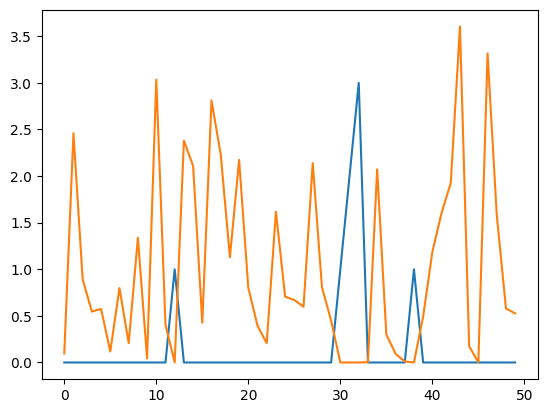

In [5]:
plt.plot(X[:T_max,vertex_idx,-1].reshape(-1,1))
plt.plot(X[:T_max,vertex_idx,0].reshape(-1,1))

# Training


In [7]:
lr = 1e-3

for weight_decay in [1e-2]:
    for hidden_dim in [16]:
        print(f"========================HIDDEN_DIM: {hidden_dim}=============================")

        model = GLSTM_v2(N=N, edge_index=edge_index, in_channels=X_train.shape[-1], hidden_size=hidden_dim,
                            out_channels=horizon, lstm_layers=1, learn_adj=True, dropout=0.1).to(device)

        model.apply(reset_weights)        
        window_folder = os.path.join("..", "Experiments", "dataset_24_25_26_03 (SOFTPLUS_MOD_01)", f"WINDOW_{window_size}_HORIZON_{horizon}_MSE_LSTM_1_DROP_0.1")

        exp_path = create_next_experiment_folder(window_folder)


        TEST_ITER = 1
        for j in range(TEST_ITER):  
            #print(f"========================ITERATION {j}=============================")
            model.apply(reset_weights)
            model, hist, summary = train_stable(
                model           = model, 
                train_loader    = train_loader, 
                val_loader      = val_loader, 
                hidden_dim      = hidden_dim, 
                train_period    = window_size,
                epochs          = 300, 
                lr              = lr, 
                weight_decay    = weight_decay, 
                patience        = 30, 
                criterion       = nn.MSELoss(),
                run_dir         = os.path.join(exp_path)
            )
            
        model.eval()
        with torch.no_grad():
            pred  = model(X_test.to(device)).detach().cpu()
            pred_denormalized      = torch.expm1(pred)
            y_test_denormalized    = torch.expm1(y_test_log)
        

        daily_mean = torch.mean(y_test_denormalized[:T_max,:,:], dim=-1)


        plt.figure(figsize=(10,10))
        plt.axhline(y=y_test_denormalized.mean().item(), color='gray', linestyle='--', label='média histórica')
        plt.plot(daily_mean.reshape(-1,1), label='média diária')
        plt.xlim(0,daily_mean.shape[0])
        plt.plot(pred_denormalized[:T_max,:,vertex_idx].reshape(-1,1), label='previsão')
        plt.plot(y_test_denormalized[:T_max,:,vertex_idx].reshape(-1,1), label='real')
        plt.legend()
        plt.savefig(os.path.join(exp_path, "previsão.png"))
        plt.close()

========================HIDDEN_DIM: 16=============================
train_batched_only_stable: use_amp=False adj_lr_factor=0.25
epoch=1/300train_loss=1.686041e+00/val_loss=1.552144e+00/train_mae=8.641389e-01/val_mae=8.180261e-01/val_mape=1.391155e+04/val_r2=-1.650864e-01/val_r2_batch=-1.382418e-01/val_r2_d1=-1.650864e-01
epoch=2/300train_loss=1.614103e+00/val_loss=1.500002e+00/train_mae=8.668446e-01/val_mae=8.324244e-01/val_mape=1.623832e+04/val_r2=-1.245665e-01/val_r2_batch=-1.006193e-01/val_r2_d1=-1.245665e-01
epoch=3/300train_loss=1.547848e+00/val_loss=1.453073e+00/train_mae=8.717320e-01/val_mae=8.470359e-01/val_mape=1.850122e+04/val_r2=-8.747717e-02/val_r2_batch=-6.703198e-02/val_r2_d1=-8.747717e-02
epoch=4/300train_loss=1.484735e+00/val_loss=1.410253e+00/train_mae=8.763775e-01/val_mae=8.611412e-01/val_mape=2.066678e+04/val_r2=-5.307524e-02/val_r2_batch=-3.663323e-02/val_r2_d1=-5.307524e-02
epoch=5/300train_loss=1.427767e+00/val_loss=1.370266e+00/train_mae=8.843842e-01/val_mae=8.73

# Post Train analysis


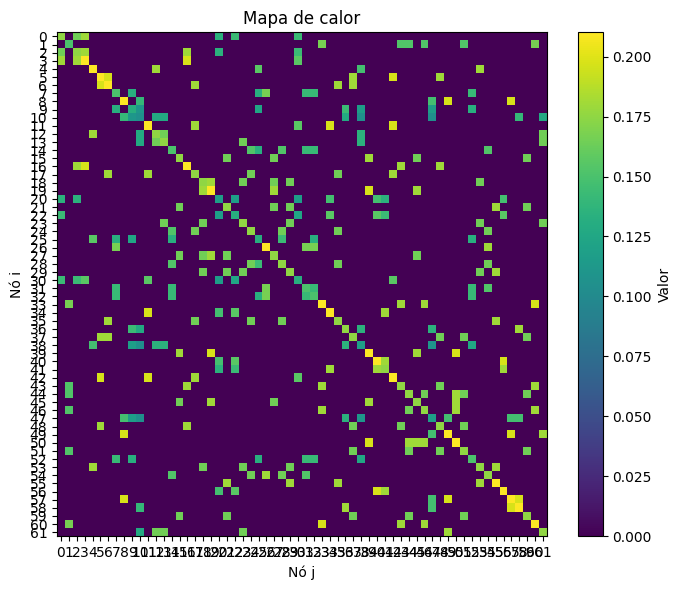

(array([3466.,    0.,    0.,    0.,    4.,   22.,   70.,  136.,   99.,
          47.]),
 array([0.        , 0.02101261, 0.04202521, 0.06303782, 0.08405042,
        0.10506303, 0.12607564, 0.14708824, 0.16810085, 0.18911345,
        0.21012606]),
 <BarContainer object of 10 artists>)

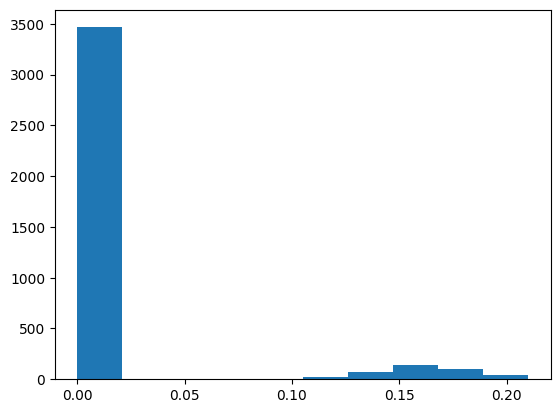

In [ ]:
plot_heatmap_nn(model.cell_0.current_adjacency())
plt.hist(model.cell_0.current_adjacency().detach().cpu().reshape(-1,1))

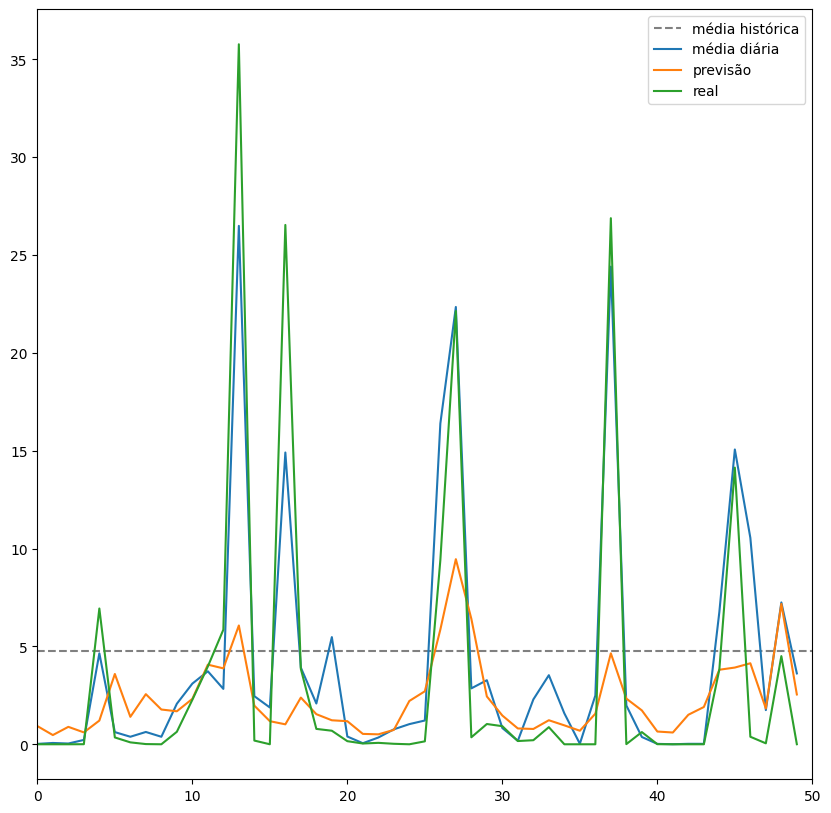

: 

In [ ]:
pred_train = model(X_train[:T_max]).detach().cpu()

pred_denormalized = torch.expm1(pred_train)
y_test_denormalized    = torch.expm1(y_train)

daily_mean = torch.mean(y_test_denormalized[:T_max,:,:], dim=-1)


plt.figure(figsize=(10,10))
plt.axhline(y=y_test_denormalized.mean().item(), color='gray', linestyle='--', label='média histórica')
plt.plot(daily_mean.reshape(-1,1), label='média diária')
plt.xlim(0,daily_mean.shape[0])
plt.plot(pred_denormalized[:T_max,:,vertex_idx].reshape(-1,1), label='previsão')
plt.plot(y_test_denormalized[:T_max,:,vertex_idx].reshape(-1,1), label='real')
plt.legend()